
# __Atividade Integradora - Relatório Operacional de Pré-Decolagem__

### Data: 03-09-2026
> ## Curso: Ciência da Computação



In [182]:
# Instalação das bibliotecas

'''!pip install -q -U watermark
!pip install pandas numpy matplotlib seaborn watermark'''

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%reload_ext watermark
%watermark -a "Grupo: Matheus dos Anjos" --iversions

Author: Grupo: Matheus dos Anjos,    ,     

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
seaborn   : 0.13.2



In [185]:
# Criação do dataset (conjunto de dados)
dataset1 = pd.read_csv('/content/telemetry_baseline.csv')

In [186]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   internal_temp_c          500 non-null    float64
 2   external_temp_c          500 non-null    float64
 3   battery_voltage_v        500 non-null    float64
 4   battery_current_a        500 non-null    float64
 5   battery_soc_percent      500 non-null    float64
 6   battery_capacity_ah      500 non-null    float64
 7   energy_available_kwh     500 non-null    float64
 8   power_load_kw            500 non-null    float64
 9   energy_loss_percent      500 non-null    float64
 10  tank_pressure_bar        500 non-null    float64
 11  structural_integrity     500 non-null    int64  
 12  critical_modules_status  500 non-null    int64  
 13  telemetry_link_status    500 non-null    int64  
 14  estimated_autonomy_min   5

In [187]:
dataset1.describe()

,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.0,500.0,500.00000
mean,26.475240,11.868340,49.105340,69.647700,79.993940,100.198580,3.934996,14.956940,4.897400,119.367480,1.0,1.0,1.0,112.61380
std,5.077737,9.992361,1.783217,28.701117,11.432272,11.829074,0.740334,5.659599,1.740278,14.141079,0.0,0.0,0.0,39.26878
min,18.090000,-4.840000,46.030000,20.320000,60.060000,80.000000,2.385700,5.040000,2.000000,95.000000,1.0,1.0,1.0,45.00000
25%,22.100000,3.015000,47.445000,44.107500,70.725000,90.395000,3.383300,9.995000,3.390000,107.025000,1.0,1.0,1.0,78.52500
50%,26.725000,11.515000,49.240000,70.890000,79.840000,100.070000,3.863700,15.375000,4.750000,120.005000,1.0,1.0,1.0,110.80000
75%,30.850000,20.422500,50.665000,93.740000,89.732500,110.715000,4.452650,19.515000,6.502500,129.925000,1.0,1.0,1.0,147.60000
max,34.880000,29.990000,52.000000,119.830000,99.820000,119.910000,6.065100,24.980000,8.000000,144.890000,1.0,1.0,1.0,179.60000


In [188]:
# Número de linhas
n_rows = 500

# Gerar timestamps sequenciais começando de uma data recente
start_time = pd.to_datetime('2026-09-03 12:00:00')
timestamps = pd.to_datetime([start_time + pd.Timedelta(minutes=i) for i in range(n_rows)])

# Gerar dados aleatórios dentro dos intervalos especificados
internal_temp_c = np.random.uniform(21, 35, n_rows)
external_temp_c = np.random.uniform(-1, 30, n_rows)
battery_voltage_v = np.random.uniform(46, 52, n_rows)
battery_current_a = np.random.uniform(20, 120, n_rows)
battery_soc_percent = np.random.uniform(71, 100, n_rows)
battery_capacity_ah = np.random.uniform(80, 120, n_rows)
power_load_kw = np.random.uniform(5, 25, n_rows)
energy_loss_percent = np.random.uniform(2, 8, n_rows)
tank_pressure_bar = np.random.uniform(101, 145, n_rows)

# ITEM 1.4 - ANÁLISE ENERGÉTICA
# 1. Energia Disponível Bruta
energy_available_kwh = (battery_voltage_v * battery_capacity_ah * battery_soc_percent / 100) / 1000
# 2. Descontar as perdas energéticas (%) do sistema para obter a Energia Útil
energia_util_kwh = energy_available_kwh * (1 - (energy_loss_percent / 100))
# 3. Calcular a Autonomia em Horas (Energia / Consumo) e converter para Minutos (* 60)
estimated_autonomy_min = (energia_util_kwh / power_load_kw) * 60

# Definir estados fixos
structural_integrity = np.ones(n_rows, dtype=int)
critical_modules_status = np.ones(n_rows, dtype=int)
telemetry_link_status = np.ones(n_rows, dtype=int)


# Determinar decisao_de_lancamento
# Para simplificar, vamos definir algumas condições seguras para 'READY' (PRONTO)
# Exemplo: temp_interna > 20, temp_externa > -2, soc_bateria > 70, pressao_tanque > 100
launch_decision = []
for i in range(n_rows):
    if (internal_temp_c[i] > 20 and
        external_temp_c[i] > -2 and
        battery_soc_percent[i] > 70 and
        tank_pressure_bar[i] > 100 and
        structural_integrity[i] == 1 and
        critical_modules_status[i] == 1 and
        telemetry_link_status[i] == 1):
        launch_decision.append('READY')
    else:
        launch_decision.append('ABORT')

# Criar DataFrame
synthetic_data = pd.DataFrame({
    'timestamp': timestamps,
    'internal_temp_c': internal_temp_c,
    'external_temp_c': external_temp_c,
    'battery_voltage_v': battery_voltage_v,
    'battery_current_a': battery_current_a,
    'battery_soc_percent': battery_soc_percent,
    'battery_capacity_ah': battery_capacity_ah,
    'energy_available_kwh': energy_available_kwh,
    'power_load_kw': power_load_kw,
    'energy_loss_percent': energy_loss_percent,
    'tank_pressure_bar': tank_pressure_bar,
    'structural_integrity': structural_integrity,
    'critical_modules_status': critical_modules_status,
    'telemetry_link_status': telemetry_link_status,
    'estimated_autonomy_min': estimated_autonomy_min,
    'launch_decision': launch_decision
})

# Salvar para CSV
output_csv_path = 'synthetic_telemetry_data.csv'
synthetic_data.to_csv(output_csv_path, index=False)

print(f"Dataset sintético salvo em '{output_csv_path}'")

Dataset sintético salvo em 'synthetic_telemetry_data.csv'


In [189]:
# ITEM 1.3 - SIMULAÇÃO (VERIFICAÇÃO IMPRESSA)

print("-" * 60)
print("SIMULAÇÃO DE VERIFICAÇÃO DE PRÉ-DECOLAGEM")
print("-" * 60)
registro_teste = synthetic_data.iloc[0]
print(f"Leitura de Telemetria no instante {registro_teste['timestamp']}:")
print(f"-> Temperatura Interna: {registro_teste['internal_temp_c']:.2f} °C")
print(f"-> Bateria Restante: {registro_teste['battery_soc_percent']:.1f} %")
print(f"-> Autonomia Calculada: {registro_teste['estimated_autonomy_min']:.1f} minutos")
print(f"-> Pressão do Tanque: {registro_teste['tank_pressure_bar']:.1f} bar")
print("-" * 60)
print(f"VEREDITO FINAL DO SISTEMA: {registro_teste['launch_decision']}")
print("-" * 60)

------------------------------------------------------------
SIMULAÇÃO DE VERIFICAÇÃO DE PRÉ-DECOLAGEM
------------------------------------------------------------
Leitura de Telemetria no instante 2026-09-03 12:00:00:
-> Temperatura Interna: 21.79 °C
-> Bateria Restante: 95.6 %
-> Autonomia Calculada: 12.2 minutos
-> Pressão do Tanque: 102.5 bar
------------------------------------------------------------
VEREDITO FINAL DO SISTEMA: READY
------------------------------------------------------------


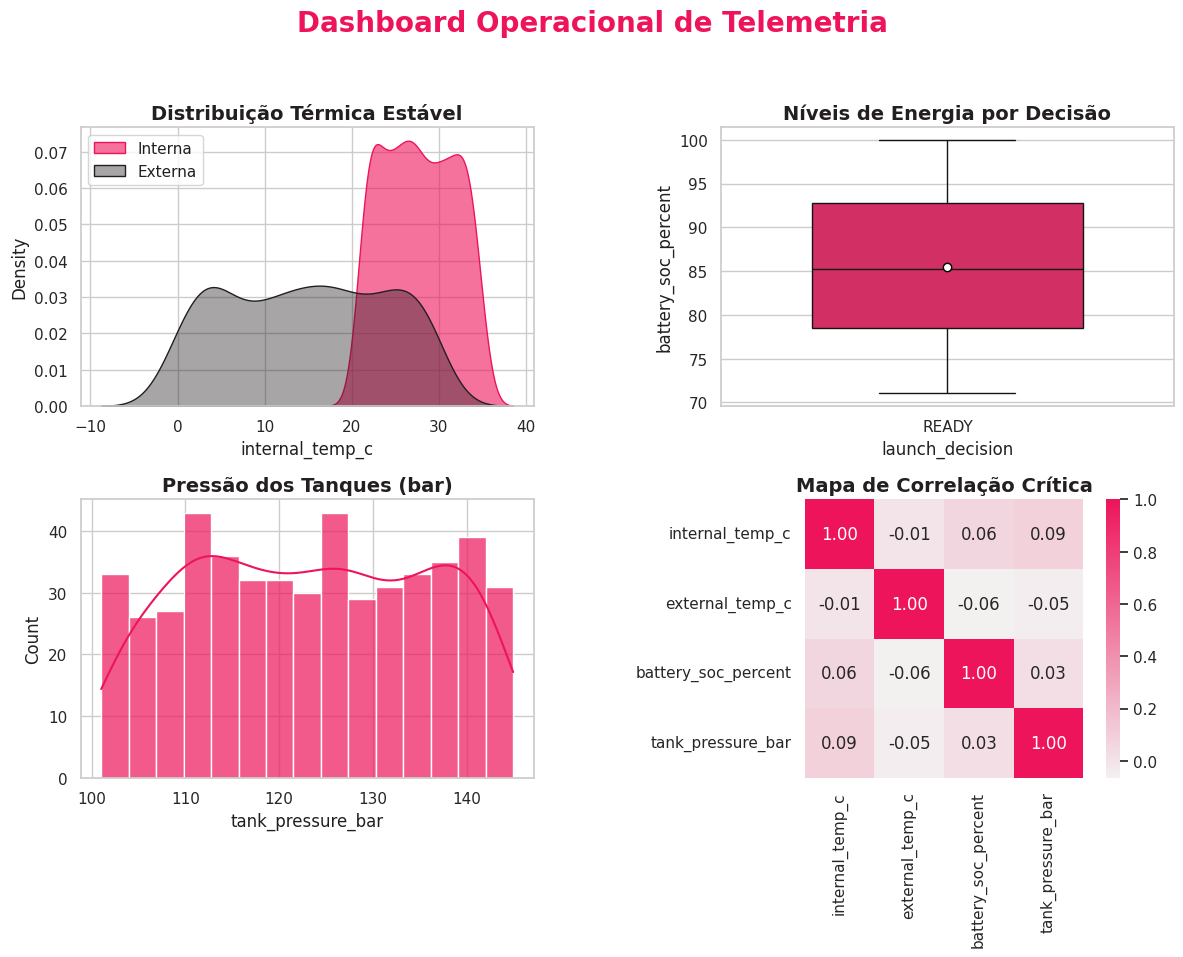

In [190]:
# Carregar dados
resultado1 = pd.read_csv('/content/synthetic_telemetry_data.csv')
corr = resultado1[['internal_temp_c', 'external_temp_c', 'battery_soc_percent', 'tank_pressure_bar']].corr()

# Definição da Identidade Visual FIAP
fiap_pink = '#ED145B'
fiap_dark = '#231F20'

# Configurações globais de elegância
sns.set_theme(style="whitegrid")
plt.rcParams['text.color'] = fiap_dark
plt.rcParams['axes.labelcolor'] = fiap_dark

# Layout ajustado para 10x8 para melhor encaixe na tela do Colab
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dashboard Operacional de Telemetria', fontsize=20, fontweight='bold', color=fiap_pink, y=0.98)

# 1. Temperatura
sns.kdeplot(data=resultado1, x='internal_temp_c', fill=True, color=fiap_pink, label='Interna', ax=axes[0, 0], alpha=0.6)
sns.kdeplot(data=resultado1, x='external_temp_c', fill=True, color=fiap_dark, label='Externa', ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title('Distribuição Térmica Estável', fontsize=14, fontweight='bold')
axes[0, 0].legend(frameon=True)

# 2. Energia
sns.boxplot(data=resultado1, x='launch_decision', y='battery_soc_percent',
            palette={'READY': fiap_pink, 'ABORT': fiap_dark}, ax=axes[0, 1], hue='launch_decision',
            legend=False, showmeans=True, meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"}, width=0.6)
axes[0, 1].set_title('Níveis de Energia por Decisão', fontsize=14, fontweight='bold')

# 3. Pressão
ax3 = sns.histplot(resultado1['tank_pressure_bar'], bins=15, color=fiap_pink, ax=axes[1, 0], kde=True, alpha=0.7)
axes[1, 0].set_title('Pressão dos Tanques (bar)', fontsize=14, fontweight='bold')

# 4. Correlação
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.light_palette(fiap_pink, as_cmap=True), ax=axes[1, 1], cbar=True, square=True)
axes[1, 1].set_title('Mapa de Correlação Crítica', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [191]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   internal_temp_c          500 non-null    float64
 2   external_temp_c          500 non-null    float64
 3   battery_voltage_v        500 non-null    float64
 4   battery_current_a        500 non-null    float64
 5   battery_soc_percent      500 non-null    float64
 6   battery_capacity_ah      500 non-null    float64
 7   energy_available_kwh     500 non-null    float64
 8   power_load_kw            500 non-null    float64
 9   energy_loss_percent      500 non-null    float64
 10  tank_pressure_bar        500 non-null    float64
 11  structural_integrity     500 non-null    int64  
 12  critical_modules_status  500 non-null    int64  
 13  telemetry_link_status    500 non-null    int64  
 14  estimated_autonomy_min   5

In [192]:
dataset2.describe()

,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,26.795740,11.868340,49.105340,69.647700,79.229100,100.198580,3.897045,14.956940,4.897400,119.391140,0.988000,0.994000,0.992000,112.61380
std,6.140096,9.992361,1.783217,28.701117,13.277407,11.829074,0.811057,5.659599,1.740278,15.450327,0.108994,0.077304,0.089173,39.26878
min,18.090000,-4.840000,46.030000,20.320000,13.630000,80.000000,0.668800,5.040000,2.000000,49.310000,0.000000,0.000000,0.000000,45.00000
25%,22.100000,3.015000,47.445000,44.107500,70.362500,90.395000,3.365975,9.995000,3.390000,106.970000,1.000000,1.000000,1.000000,78.52500
50%,26.725000,11.515000,49.240000,70.890000,79.625000,100.070000,3.862250,15.375000,4.750000,119.955000,1.000000,1.000000,1.000000,110.80000
75%,30.935000,20.422500,50.665000,93.740000,89.237500,110.715000,4.447950,19.515000,6.502500,130.045000,1.000000,1.000000,1.000000,147.60000
max,63.540000,29.990000,52.000000,119.830000,99.820000,119.910000,6.065000,24.980000,8.000000,202.410000,1.000000,1.000000,1.000000,179.60000


In [193]:
# Criar uma cópia dos dados sintéticos originais para introduzir anomalias
anomalous_data = synthetic_data.copy()

# Adicionar a coluna 'anomalia_inserida', inicializada como 'nao'
anomalous_data['anomalia_inserida'] = 'nao'

# Determinar o número de linhas para inserir anomalias (3%)
num_anomalies = int(len(anomalous_data) * 0.03)

# Obter índices aleatórios para inserir as anomalias
anomalous_indices = np.random.choice(anomalous_data.index, num_anomalies, replace=False)

# Definir tipos de anomalias e suas ações correspondentes
anomaly_types = [
    'internal_temp_c_high', 'battery_soc_low', 'tank_pressure_out_of_range',
    'structural_integrity_fail', 'critical_modules_fail', 'telemetry_link_fail'
]

# Introduzir anomalias
for idx in anomalous_indices:
    anomalous_data.loc[idx, 'anomalia_inserida'] = 'sim'

    # Selecionar aleatoriamente um tipo de anomalia para cada linha escolhida
    chosen_anomaly = np.random.choice(anomaly_types)

    if chosen_anomaly == 'internal_temp_c_high':
        anomalous_data.loc[idx, 'internal_temp_c'] = np.random.uniform(45, 70)
    elif chosen_anomaly == 'battery_soc_low':
        anomalous_data.loc[idx, 'battery_soc_percent'] = np.random.uniform(5, 25)
    elif chosen_anomaly == 'tank_pressure_out_of_range':
        if np.random.rand() > 0.5: # 50% de chance para faixa menor ou maior
            anomalous_data.loc[idx, 'tank_pressure_bar'] = np.random.uniform(40, 80)
        else:
            anomalous_data.loc[idx, 'tank_pressure_bar'] = np.random.uniform(160, 220)
    elif chosen_anomaly == 'structural_integrity_fail':
        anomalous_data.loc[idx, 'structural_integrity'] = 0
    elif chosen_anomaly == 'critical_modules_fail':
        anomalous_data.loc[idx, 'critical_modules_status'] = 0
    elif chosen_anomaly == 'telemetry_link_fail':
        anomalous_data.loc[idx, 'telemetry_link_status'] = 0

# Recalcular energy_available_kwh para todo o dataset
anomalous_data['energy_available_kwh'] = (
    anomalous_data['battery_voltage_v'] *
    anomalous_data['battery_capacity_ah'] *
    anomalous_data['battery_soc_percent'] / 100
) / 1000

# Recalcular decisao_de_lancamento para todo o dataset
# Usando as mesmas condições seguras de antes:
# temp_interna > 20, temp_externa > -2, soc_bateria > 70,
# pressao_tanque > 100, integridade_estrutural == 1, status_modulos_criticos == 1, status_link_telemetria == 1

anomalous_data['launch_decision'] = 'ABORT'
safe_conditions = (
    (anomalous_data['internal_temp_c'] > 20) &
    (anomalous_data['external_temp_c'] > -2) &
    (anomalous_data['battery_soc_percent'] > 70) &
    (anomalous_data['tank_pressure_bar'] > 100) &
    (anomalous_data['structural_integrity'] == 1) &
    (anomalous_data['critical_modules_status'] == 1) &
    (anomalous_data['telemetry_link_status'] == 1)
)
anomalous_data.loc[safe_conditions, 'launch_decision'] = 'READY'

# Salvar o dataset com anomalias em um novo CSV
anomalous_output_csv_path = 'anomalous_telemetry_data.csv'
anomalous_data.to_csv(anomalous_output_csv_path, index=False)

print(f"Dataset sintético com anomalias salvo em '{anomalous_output_csv_path}'")

Dataset sintético com anomalias salvo em 'anomalous_telemetry_data.csv'


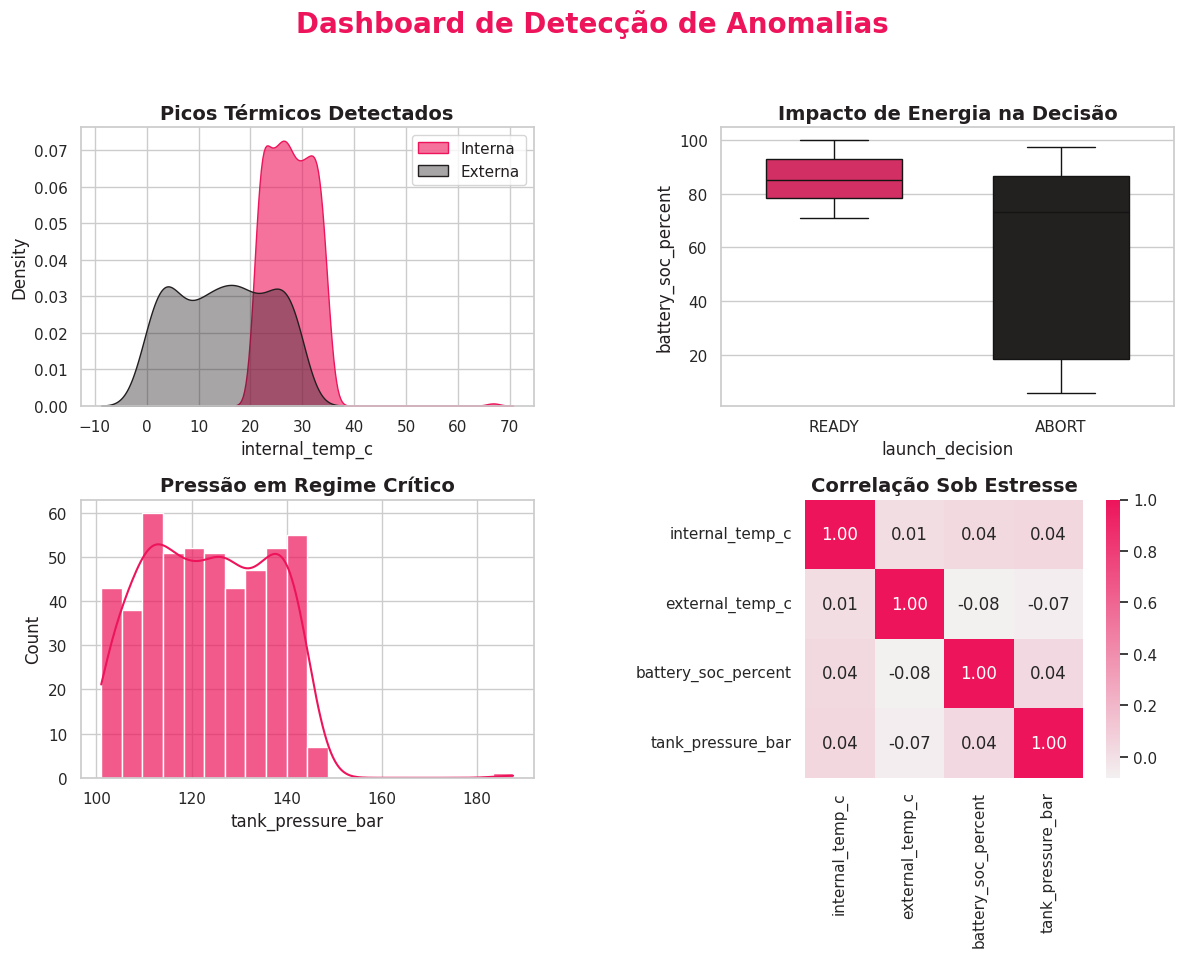

In [194]:
# Carregar dados de anomalias
resultado2 = pd.read_csv('/content/anomalous_telemetry_data.csv')
corr_anomalous = resultado2[['internal_temp_c', 'external_temp_c', 'battery_soc_percent', 'tank_pressure_bar']].corr()

# Layout ajustado para elegância e encaixe
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dashboard de Detecção de Anomalias', fontsize=20, fontweight='bold', color=fiap_pink, y=0.98)

# 1. Temperatura (Anomalias)
sns.kdeplot(data=resultado2, x='internal_temp_c', fill=True, color=fiap_pink, label='Interna', ax=axes[0, 0], alpha=0.6)
sns.kdeplot(data=resultado2, x='external_temp_c', fill=True, color=fiap_dark, label='Externa', ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title('Picos Térmicos Detectados', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# 2. Energia (Anomalias)
sns.boxplot(data=resultado2, x='launch_decision', y='battery_soc_percent',
            palette={'READY': fiap_pink, 'ABORT': fiap_dark}, ax=axes[0, 1], hue='launch_decision', legend=False, width=0.6)
axes[0, 1].set_title('Impacto de Energia na Decisão', fontsize=14, fontweight='bold')

# 3. Pressão (Anomalias)
sns.histplot(resultado2['tank_pressure_bar'], bins=20, color=fiap_pink, ax=axes[1, 0], kde=True, alpha=0.7)
axes[1, 0].set_title('Pressão em Regime Crítico', fontsize=14, fontweight='bold')

# 4. Correlação (Anomalias)
sns.heatmap(corr_anomalous, annot=True, fmt='.2f', cmap=sns.light_palette(fiap_pink, as_cmap=True), ax=axes[1, 1], cbar=True, square=True)
axes[1, 1].set_title('Correlação Sob Estresse', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [195]:
dataset2.groupby("launch_decision")["battery_soc_percent"].describe()

,count,mean,std,min,25%,50%,75%,max
launch_decision,,,,,,,,
ABORT,15.0,55.054000,33.863713,13.63,17.87,72.00,84.31,98.02
READY,485.0,79.976784,11.397794,60.22,70.47,79.77,89.60,99.82


In [196]:
dataset2[["internal_temp_c", "external_temp_c"]].describe()

,internal_temp_c,external_temp_c
count,500.000000,500.000000
mean,26.795740,11.868340
std,6.140096,9.992361
min,18.090000,-4.840000
25%,22.100000,3.015000
50%,26.725000,11.515000
75%,30.935000,20.422500
max,63.540000,29.990000


In [197]:
dataset2.groupby("launch_decision")["battery_soc_percent"].describe()

,count,mean,std,min,25%,50%,75%,max
launch_decision,,,,,,,,
ABORT,15.0,55.054000,33.863713,13.63,17.87,72.00,84.31,98.02
READY,485.0,79.976784,11.397794,60.22,70.47,79.77,89.60,99.82


In [198]:
dataset2["tank_pressure_bar"].describe()

,tank_pressure_bar
count,500.000000
mean,119.391140
std,15.450327
min,49.310000
25%,106.970000
50%,119.955000
75%,130.045000
max,202.410000


### Fluxograma de decisão
> Nesta seção, o fluxo de para decidir se teremos autorização para decolar ou abortar.

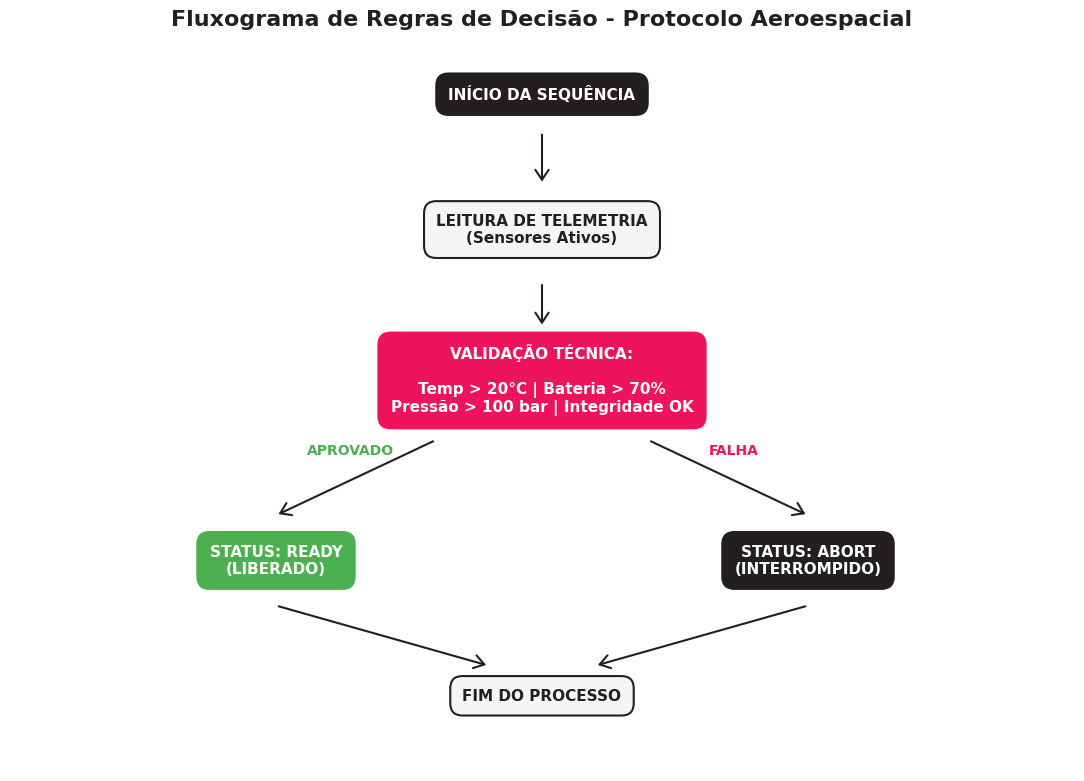

In [200]:
# ITEM 1.2 - Algoritmo de verificação
def plotar_fluxograma_elegante():
    # Paleta de Cores
    fiap_pink = '#ED145B'
    fiap_dark = '#231F20'
    verde_sucesso = '#4CAF50'
    cinza_claro = '#F5F5F5'

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.axis('off') # Oculta os eixos cartesianos

    # Estilização dinâmica das caixas (bbox)
    style_base = dict(boxstyle="round,pad=0.8", lw=1.5)
    box_inicio = {**style_base, 'facecolor': fiap_dark, 'edgecolor': fiap_dark}
    box_leitura = {**style_base, 'facecolor': cinza_claro, 'edgecolor': fiap_dark}
    box_condicao = {**style_base, 'facecolor': fiap_pink, 'edgecolor': fiap_pink}
    box_ready = {**style_base, 'facecolor': verde_sucesso, 'edgecolor': verde_sucesso}
    box_abort = {**style_base, 'facecolor': fiap_dark, 'edgecolor': fiap_dark}

    # Configuração global de tipografia
    font_branca = dict(color='white', fontweight='bold', fontsize=11, ha='center', va='center')
    font_escura = dict(color=fiap_dark, fontweight='bold', fontsize=11, ha='center', va='center')

    # 1. Plotagem dos Nós (Caixas) baseadas no eixo Y para hierarquia vertical
    ax.text(0.5, 0.90, "INÍCIO DA SEQUÊNCIA", bbox=box_inicio, **font_branca)

    ax.text(0.5, 0.72, "LEITURA DE TELEMETRIA\n(Sensores Ativos)", bbox=box_leitura, **font_escura)

    condicoes = ("VALIDAÇÃO TÉCNICA:\n\n"
                 "Temp > 20°C | Bateria > 70%\n"
                 "Pressão > 100 bar | Integridade OK")
    ax.text(0.5, 0.52, condicoes, bbox=box_condicao, **font_branca)

    ax.text(0.25, 0.28, "STATUS: READY\n(LIBERADO)", bbox=box_ready, **font_branca)
    ax.text(0.75, 0.28, "STATUS: ABORT\n(INTERROMPIDO)", bbox=box_abort, **font_branca)

    ax.text(0.5, 0.10, "FIM DO PROCESSO", bbox=box_leitura, **font_escura)

    # 2. Lógica das Setas de Transição
    def ligar_nos(xy_from, xy_to):
        ax.annotate("", xy=xy_to, xycoords='data', xytext=xy_from, textcoords='data',
                    arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6",
                                    color=fiap_dark, lw=1.5))

    # Setas Lineares (Descida padrão)
    ligar_nos((0.5, 0.85), (0.5, 0.78)) # Início -> Leitura
    ligar_nos((0.5, 0.65), (0.5, 0.59)) # Leitura -> Condição

    # Setas de Bifurcação (Desvio das quinas inferiores da caixa de condição)
    ligar_nos((0.40, 0.44), (0.25, 0.34)) # Condição -> READY
    ligar_nos((0.60, 0.44), (0.75, 0.34)) # Condição -> ABORT

    # Setas de Convergência (Descida para o Fim)
    ligar_nos((0.25, 0.22), (0.45, 0.14)) # READY -> Fim
    ligar_nos((0.75, 0.22), (0.55, 0.14)) # ABORT -> Fim

    # 3. Rótulos das Regras de Negócio (Sim/Não)
    ax.text(0.32, 0.42, "APROVADO", color=verde_sucesso, fontweight='bold', fontsize=10, ha='center')
    ax.text(0.68, 0.42, "FALHA", color=fiap_pink, fontweight='bold', fontsize=10, ha='center')

    # Título do Gráfico
    plt.title("Fluxograma de Regras de Decisão - Protocolo Aeroespacial",
              fontsize=16, fontweight='black', color=fiap_dark, y=0.98)

    plt.tight_layout()
    plt.show()

# Executa e exibe o fluxograma
plotar_fluxograma_elegante()